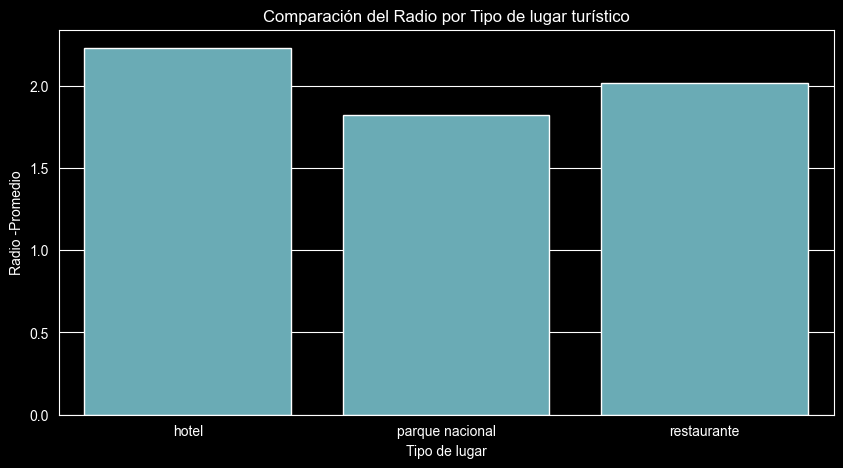

In [8]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.metrics import calculo_radio,calculo_densidad_lex
from src.analysis.pos_analyzer import distribucion_pos
#Se llama al df
df = pd.read_csv("../data/processed/resenas_pos_tagged.csv")

df["tokens_spacy"] = df["tokens_spacy"].apply(ast.literal_eval)

df["radio"] = df["tokens_spacy"].apply(calculo_radio)
df["densidad_lexica"] = df["tokens_spacy"].apply(calculo_densidad_lex)

df_lugares = df.groupby("tipo_lugar")[["radio","densidad_lexica"]].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=df_lugares,x="tipo_lugar",y="radio", color="#5DB4C2")
plt.title("Comparación del Radio por Tipo de lugar turístico")
plt.xlabel("Tipo de lugar")
plt.ylabel("Radio -Promedio")
plt.savefig("../outputs/figures/comparacion_lugares.png")
plt.show()